In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import StrMethodFormatter
import plotly.express as px

PROCESSED_DATA_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images")

df = pd.read_csv(PROCESSED_DATA_DIR / "cyclistic_2019_cleaned.csv")

sns.set_theme(style="whitegrid", font_scale=1.05)

palette = {
    "Casual Rider": "#F97316",
    "Annual Member": "#2563EB"
}

## Usertype Usage by Day of Week

In [12]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_counts = (
	df.groupby(["rider_type", "day_of_week"])
	.size()
	.reset_index(name="ride_count")
)

day_counts["day_of_week"] = pd.Categorical(
	day_counts["day_of_week"],
  categories=day_order,
  ordered=True
)

day_counts = day_counts.sort_values("day_of_week")

day_counts.head(14)

,rider_type,day_of_week,ride_count
1,Annual Member,Monday,458780
8,Casual Rider,Monday,101489
5,Annual Member,Tuesday,497025
12,Casual Rider,Tuesday,88655
6,Annual Member,Wednesday,494277
13,Casual Rider,Wednesday,89745
4,Annual Member,Thursday,486915
11,Casual Rider,Thursday,101372
0,Annual Member,Friday,456966
7,Casual Rider,Friday,121141


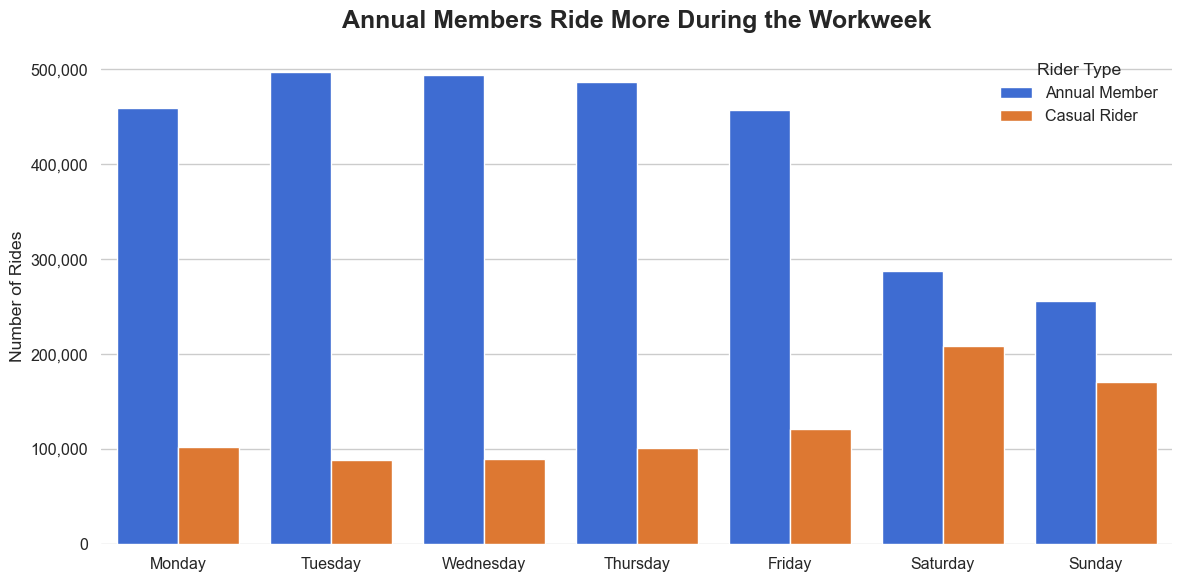

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=day_counts,
    x="day_of_week",
    y="ride_count",
    hue="rider_type",
    palette=palette
)

ax.set_title(
    "Annual Members Ride More During the Workweek",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Number of Rides")

ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.legend(
    title="Rider Type",
    frameon=False,
    loc="upper right"
)

plt.xticks(rotation=0)
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

In [14]:
fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "rides_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)

## User type usage by season

In [15]:
season_order = ["Winter", "Spring", "Summer", "Fall"]

season_counts = (
    df.groupby(["rider_type", "season"])
    .size()
    .reset_index(name="ride_count")
)

season_counts["season"] = pd.Categorical(
    season_counts['season'],
    categories=season_order,
    ordered=True
)

season_counts = season_counts.sort_values("season")
season_counts.head(10)

,rider_type,season,ride_count
3,Annual Member,Winter,330880
7,Casual Rider,Winter,23670
1,Annual Member,Spring,653088
5,Casual Rider,Spring,145291
2,Annual Member,Summer,1130155
6,Casual Rider,Summer,492739
0,Annual Member,Fall,823244
4,Casual Rider,Fall,218937


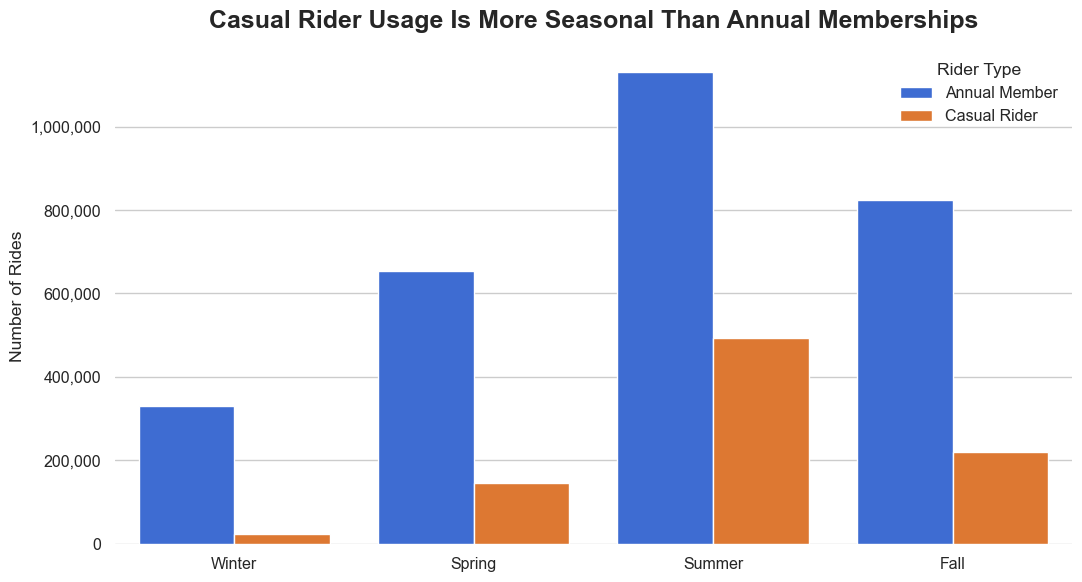

In [16]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=season_counts,
    x="season",
    y="ride_count",
    hue="rider_type",
    palette=palette
)

ax.set_title(
    "Casual Rider Usage Is More Seasonal Than Annual Memberships",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Number of Rides")

ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.legend(
    title="Rider Type",
    frameon=False
)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [17]:
fig = ax.get_figure()

fig.savefig(
    IMAGES_DIR / "seasonal_ride_demand.png",
    dpi=300,
    bbox_inches="tight"
)

## Average Trip Duration By Rider Type

In [18]:
trip_duration_summary = (
    df.groupby("rider_type")["trip_duration_minutes"]
    .mean()
    .reset_index(name="avg_trip_duration")
)

trip_duration_summary

,rider_type,avg_trip_duration
0,Annual Member,14.323055
1,Casual Rider,57.014762


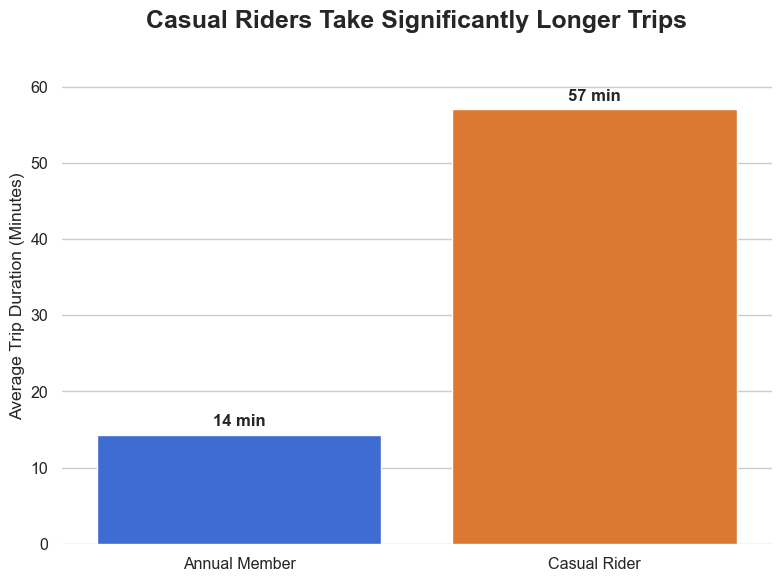

In [20]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=trip_duration_summary,
    x="rider_type",
    y="avg_trip_duration",
    hue="rider_type",
    palette=palette,
    legend=False
)

ax.set_title(
    "Casual Riders Take Significantly Longer Trips",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Average Trip Duration (Minutes)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f min",
        padding=4,
        fontsize=12,
        fontweight="bold"
    )

sns.despine(left=True, bottom=True)

ax.set_ylim(0, 65)
plt.tight_layout()
plt.show()

In [21]:
fig = ax.get_figure()

fig.savefig(
    IMAGES_DIR / "average_trip_duration.png",
    dpi=300,
    bbox_inches="tight"
)

## Ride volume by Time of Day

In [25]:
df["is_weekend"] = np.where(
    df["day_of_week"].isin(["Saturday", "Sunday"]),
    "Weekend",
    "Weekday"
)

df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")

df["hour"] = df["start_time"].dt.hour

def classify_time_of_day(row):
    hour = row["hour"]
    day = row["day_of_week"]

    if hour in [6, 7, 8]:
        return "Early Morning"

    elif hour in [9, 10]:
        return "Late Morning"

    elif hour in [11, 12]:
        return "Lunch"

    elif hour in [13, 14, 15]:
        return "Afternoon"

    elif hour in [16, 17, 18]:
        return "Late Afternoon"

    elif hour in [19, 20, 21, 22]:
        return "Evening"

    elif hour in [23, 0, 1, 2]:
        return "Late Night"

    else:
        return "Overnight"

df["time_of_day"] = df.apply(classify_time_of_day, axis=1)

time_order = [
    "Early Morning",
    "Late Morning",
    "Lunch",
    "Afternoon",
    "Late Afternoon",
    "Evening",
    "Late Night",
    "Overnight"
]

time_counts = (
    df.groupby(["rider_type", "time_of_day", "is_weekend"])
    .size()
    .reset_index(name="ride_count")
)

time_counts["time_of_day"] = pd.Categorical(
    time_counts["time_of_day"],
    categories=time_order,
    ordered=True
)

time_counts = time_counts.sort_values("time_of_day")

time_counts.head()

,rider_type,time_of_day,is_weekend,ride_count
2,Annual Member,Early Morning,Weekday,573302
3,Annual Member,Early Morning,Weekend,37663
19,Casual Rider,Early Morning,Weekend,11304
18,Casual Rider,Early Morning,Weekday,29451
25,Casual Rider,Late Morning,Weekend,35742


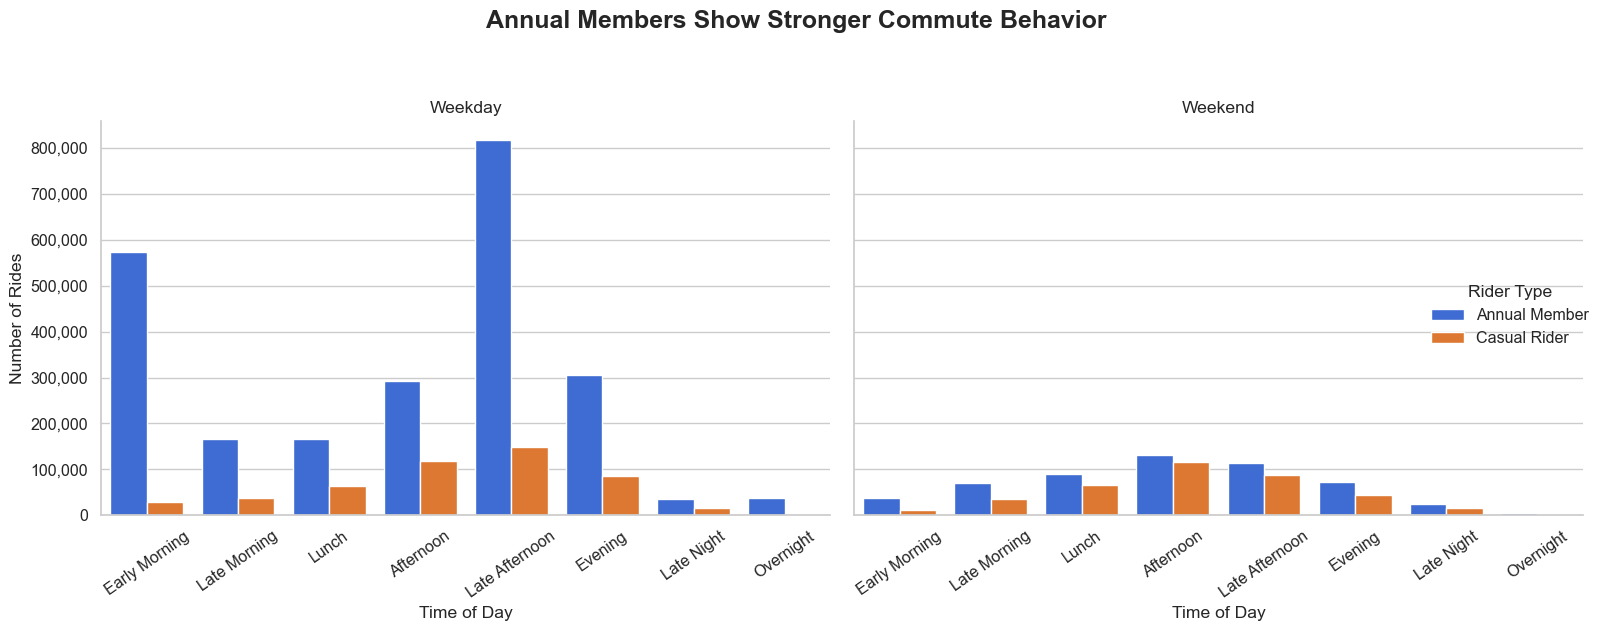

In [26]:
g = sns.catplot(
    data=time_counts,
    x="time_of_day",
    y="ride_count",
    hue="rider_type",
    col="is_weekend",
    kind="bar",
    palette=palette,
    height=6,
    aspect=1.2,
    sharey=True
)

g.set_titles("{col_name}")

g.set_axis_labels(
    "Time of Day",
    "Number of Rides"
)

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=35)
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

g.fig.suptitle(
    "Annual Members Show Stronger Commute Behavior",
    fontsize=18,
    fontweight="bold",
    y=1.05
)
g.legend.set_title("Rider Type")
plt.tight_layout()
plt.show()

In [27]:
g.savefig(
    IMAGES_DIR / "time_of_day_behavior.png",
    dpi=300,
    bbox_inches="tight"
)

## Top Start Stations By Rider Type

In [28]:
station_counts = (
    df.groupby(["rider_type", "from_station_name"])
    .size()
    .reset_index(name="ride_count")
)

station_counts.head()

,rider_type,from_station_name,ride_count
0,Annual Member,2112 W Peterson Ave,385
1,Annual Member,63rd St Beach,524
2,Annual Member,900 W Harrison St,5760
3,Annual Member,Aberdeen St & Jackson Blvd,10878
4,Annual Member,Aberdeen St & Monroe St,8249


In [29]:
top_stations = (
    station_counts
    .sort_values(
        ["rider_type", "ride_count"],
        ascending=[True, False]
    )
    .groupby("rider_type")
    .head(10)
)

top_stations.head(20)

,rider_type,from_station_name,ride_count
86,Annual Member,Canal St & Adams St,50575
152,Annual Member,Clinton St & Madison St,45990
157,Annual Member,Clinton St & Washington Blvd,45378
159,Annual Member,Columbus Dr & Randolph St,31370
252,Annual Member,Franklin St & Monroe St,30832
321,Annual Member,Kingsbury St & Kinzie St,30654
175,Annual Member,Daley Center Plaza,30423
89,Annual Member,Canal St & Madison St,27138
410,Annual Member,Michigan Ave & Washington St,25468
330,Annual Member,LaSalle St & Jackson Blvd,23021


In [30]:
top_stations["short_station_name"] = (
    top_stations["from_station_name"]
    .str.slice(0, 28)
)

In [34]:
annual_top = (
    station_counts[station_counts["rider_type"] == "Annual Member"]
    .sort_values("ride_count", ascending=False)
    .head(10)
)

casual_top = (
    station_counts[station_counts["rider_type"] == "Casual Rider"]
    .sort_values("ride_count", ascending=False)
    .head(10)
)

In [35]:
annual_top["station_label"] = annual_top["from_station_name"].str.replace(" St", " St.", regex=False)
casual_top["station_label"] = casual_top["from_station_name"].str.replace(" St", " St.", regex=False)

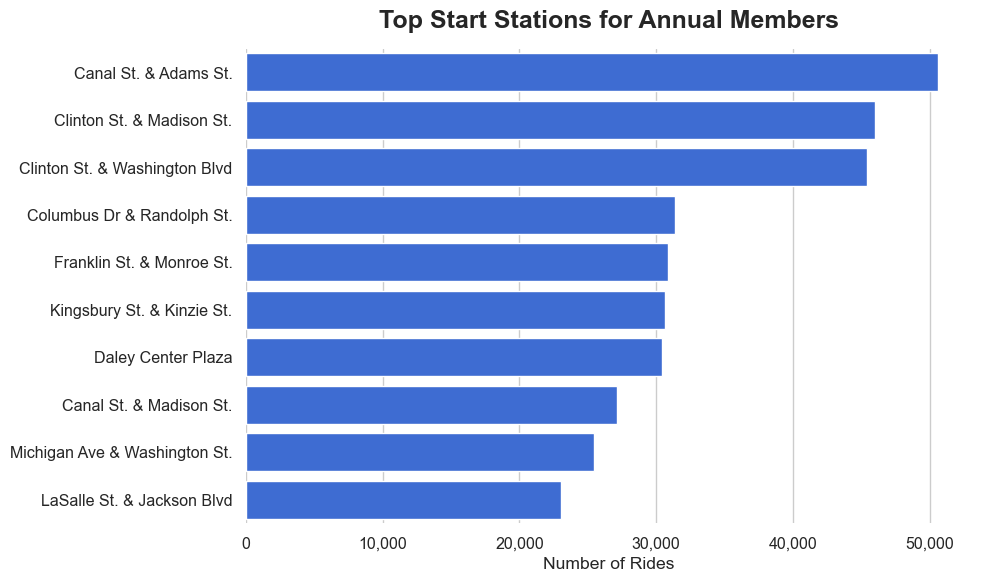

In [36]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=annual_top,
    x="ride_count",
    y="station_label",
    color=palette["Annual Member"]
)

ax.set_title(
    "Top Start Stations for Annual Members",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Rides")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [38]:
fig = ax.get_figure()

fig.savefig(
    IMAGES_DIR / "top_stations_annual_members.png",
    dpi=300,
    bbox_inches="tight"
)

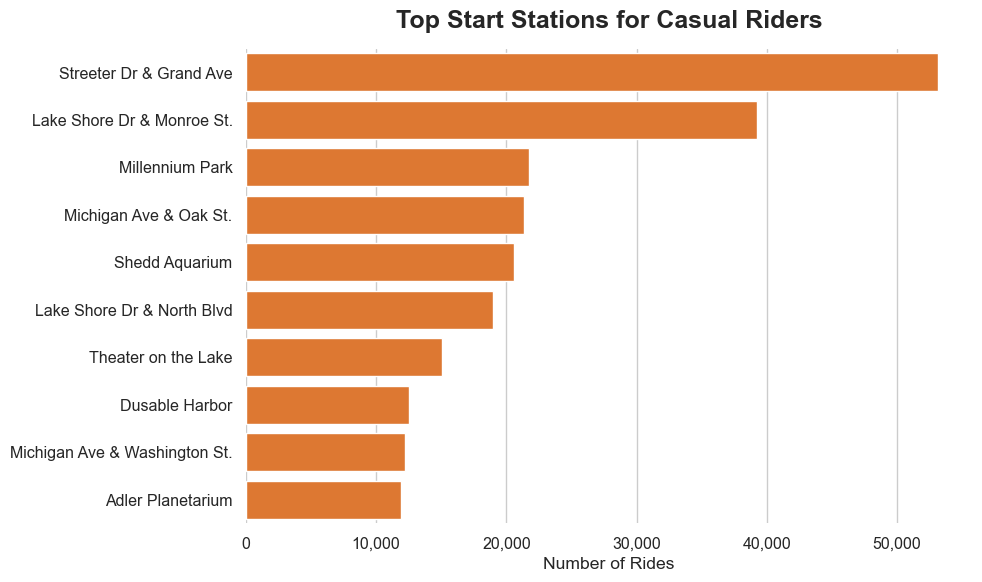

In [37]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=casual_top,
    x="ride_count",
    y="station_label",
    color=palette["Casual Rider"]
)

ax.set_title(
    "Top Start Stations for Casual Riders",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Rides")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [39]:
fig = ax.get_figure()

fig.savefig(
    IMAGES_DIR / "top_stations_casual_riders.png",
    dpi=300,
    bbox_inches="tight"
)

## Map with top stations

In [42]:
station_coordinates = pd.DataFrame({
    "from_station_name": [
        "Canal St & Adams St",
        "Clinton St & Madison St",
        "Clinton St & Washington Blvd",
        "Columbus Dr & Randolph St",
        "Franklin St & Monroe St",
        "Kingsbury St & Kinzie St",
        "Daley Center Plaza",
        "Canal St & Madison St",
        "Michigan Ave & Washington St",
        "LaSalle St & Jackson Blvd",
        "Streeter Dr & Grand Ave",
        "Lake Shore Dr & Monroe St",
        "Millennium Park",
        "Michigan Ave & Oak St",
        "Shedd Aquarium",
        "Lake Shore Dr & North Blvd",
        "Theater on the Lake",
        "Dusable Harbor",
        "Michigan Ave & Washington St",
        "Adler Planetarium"
    ],

    "latitude": [
        41.879255,
        41.882242,
        41.883380,
        41.884728,
        41.880317,
        41.889176,
        41.884241,
        41.882091,
        41.883984,
        41.878287,
        41.892278,
        41.880958,
        41.881032,
        41.900960,
        41.867226,
        41.911722,
        41.926277,
        41.886976,
        41.883984,
        41.866095
    ],

    "longitude": [
        -87.639904,
        -87.641066,
        -87.641170,
        -87.619521,
        -87.635185,
        -87.638505,
        -87.629634,
        -87.639833,
        -87.624684,
        -87.632756,
        -87.612043,
        -87.616743,
        -87.624084,
        -87.623777,
        -87.614043,
        -87.626804,
        -87.630834,
        -87.612813,
        -87.624684,
        -87.607267
    ]
})

station_coordinates.head()

,from_station_name,latitude,longitude
0,Canal St & Adams St,41.879255,-87.639904
1,Clinton St & Madison St,41.882242,-87.641066
2,Clinton St & Washington Blvd,41.883380,-87.641170
3,Columbus Dr & Randolph St,41.884728,-87.619521
4,Franklin St & Monroe St,41.880317,-87.635185


In [43]:
top_map_stations = top_stations.merge(
    station_coordinates,
    on="from_station_name",
    how="left"
)

top_map_stations.head()

,rider_type,from_station_name,ride_count,short_station_name,latitude,longitude
0,Annual Member,Canal St & Adams St,50575,Canal St & Adams St,41.879255,-87.639904
1,Annual Member,Clinton St & Madison St,45990,Clinton St & Madison St,41.882242,-87.641066
2,Annual Member,Clinton St & Washington Blvd,45378,Clinton St & Washington Blvd,41.883380,-87.641170
3,Annual Member,Columbus Dr & Randolph St,31370,Columbus Dr & Randolph St,41.884728,-87.619521
4,Annual Member,Franklin St & Monroe St,30832,Franklin St & Monroe St,41.880317,-87.635185


In [44]:
top_map_stations[
    top_map_stations["latitude"].isna()
]

,rider_type,from_station_name,ride_count,short_station_name,latitude,longitude


In [55]:
import folium

chicago_map = folium.Map(
    location=[41.89, -87.63],
    zoom_start=13.4,
    tiles="CartoDB positron"
)

# Add title
title_html = """
<h3 align="center" style="font-size:22px; margin-top:12px;">
<b>Top Cyclistic Start Stations by Rider Type</b>
</h3>
"""
chicago_map.get_root().html.add_child(folium.Element(title_html))

# Add top station markers
for _, row in top_map_stations.iterrows():

    marker_color = "blue" if row["rider_type"] == "Annual Member" else "orange"
    marker_radius = 9 if row["rider_type"] == "Annual Member" else 6

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=marker_radius,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.65,
        popup=folium.Popup(
            f"""
            <b>{row['from_station_name']}</b><br>
            Rider Type: {row['rider_type']}<br>
            Total Rides: {row['ride_count']:,}
            """,
            max_width=300
        )
    ).add_to(chicago_map)

# Add Union Station as a reference point
folium.Marker(
    location=[41.87864, -87.64025],
    popup="Union Station",
    tooltip="Union Station",
    icon=folium.Icon(
        color="red",
        icon="train",
        prefix="fa",
        icon_color="white"
)).add_to(chicago_map)

# Add legend
legend_html = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 240px;
background-color: white;
border: 2px solid #555;
z-index: 9999;
font-size: 16px;
padding: 14px;
box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
line-height: 1.8;
border-radius: 6px;
">

<b style="font-size:20px;">Map Legend</b><br>

<span style="color:blue; font-size:22px;">●</span>
Annual Member<br>

<span style="color:orange; font-size:22px;">●</span>
Casual Rider<br>

<span style="font-size:20px;">🚉</span>
Union Station

</div>
"""
chicago_map.get_root().html.add_child(folium.Element(legend_html))

chicago_map

In [56]:
chicago_map.save("../images/top_station_map.html")

## Breakdown by gender

In [57]:
gender_counts = (
    df.dropna(subset=["gender"])
    .groupby(["rider_type", "gender"])
    .size()
    .reset_index(name="ride_count")
)

gender_counts

,rider_type,gender,ride_count
0,Annual Member,Female,726539
1,Annual Member,Male,2188077
2,Casual Rider,Female,131439
3,Casual Rider,Male,212743


In [58]:
gender_counts["percent"] = (
    gender_counts.groupby("rider_type")["ride_count"]
    .transform(lambda x: x / x.sum() * 100)
)

gender_counts

,rider_type,gender,ride_count,percent
0,Annual Member,Female,726539,24.927435
1,Annual Member,Male,2188077,75.072565
2,Casual Rider,Female,131439,38.188807
3,Casual Rider,Male,212743,61.811193


In [60]:
plt.figure(figsize=(9, 6))

gender_pivot = (
    gender_counts.pivot(
        index="rider_type",
        columns="gender",
        values="percent"
    )
)

gender_pivot

gender,Female,Male
rider_type,,
Annual Member,24.927435,75.072565
Casual Rider,38.188807,61.811193


<Figure size 900x600 with 0 Axes>

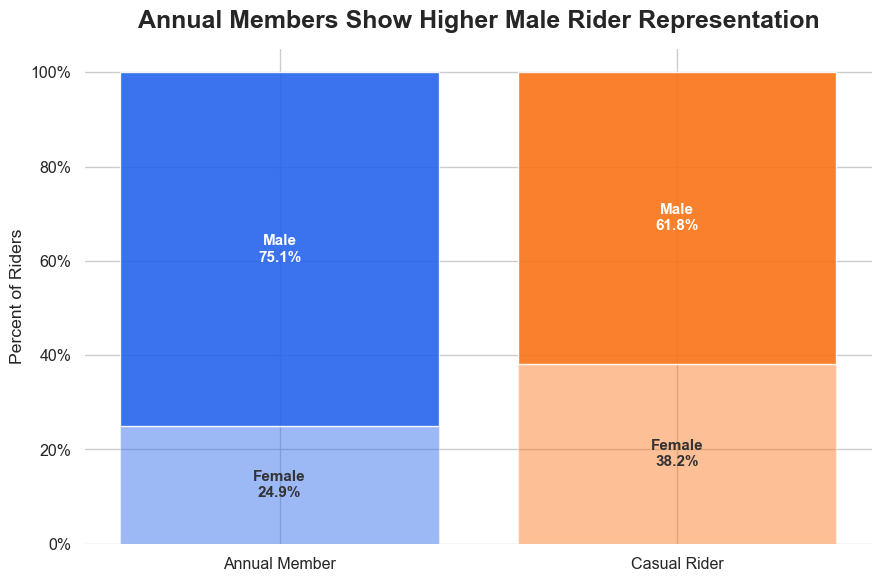

In [66]:
plt.figure(figsize=(9, 6))

rider_colors = {
    "Annual Member": "#2563EB",
    "Casual Rider": "#F97316"
}

for rider_type in gender_pivot.index:

    female_val = gender_pivot.loc[rider_type, "Female"]
    male_val = gender_pivot.loc[rider_type, "Male"]

    color = rider_colors[rider_type]

    # Female section
    plt.bar(
        rider_type,
        female_val,
        color=color,
        alpha=0.45
    )

    # Male section
    plt.bar(
        rider_type,
        male_val,
        bottom=female_val,
        color=color,
        alpha=0.9
    )

    # Female label
    plt.text(
        rider_type,
        female_val / 2,
        f"Female\n{female_val:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

    # Male label
    plt.text(
        rider_type,
        female_val + (male_val / 2),
        f"Male\n{male_val:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

plt.title(
    "Annual Members Show Higher Male Rider Representation",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.ylabel("Percent of Riders")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0f}%")
)

sns.despine(left=True, bottom=True)

plt.tight_layout()
fig = plt.gcf()

fig.savefig(
    IMAGES_DIR / "gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [64]:
fig = plt.gcf()

fig.savefig(
    IMAGES_DIR / "gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>